In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df= pd.read_csv(r"C:\Users\amnaj\OneDrive\Desktop\csv\Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [5]:
df["Gender"]= df["Gender"].map({"Male":1,"Female":0})
print(df["Gender"])

0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    1
198    1
199    1
Name: Gender, Length: 200, dtype: int64


In [6]:
X=df.drop(columns=["Gender"])
y=df["Gender"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2, random_state =42)
model= LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [7]:
y_pred= model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [8]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5

Confusion Matrix:
 [[19  2]
 [18  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.90      0.66        21
           1       0.33      0.05      0.09        19

    accuracy                           0.50        40
   macro avg       0.42      0.48      0.37        40
weighted avg       0.43      0.50      0.39        40



In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [11]:


X = df[['Gender', 'Age', 'Annual Income (k$)']]
y = df['Spending Score (1-100)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

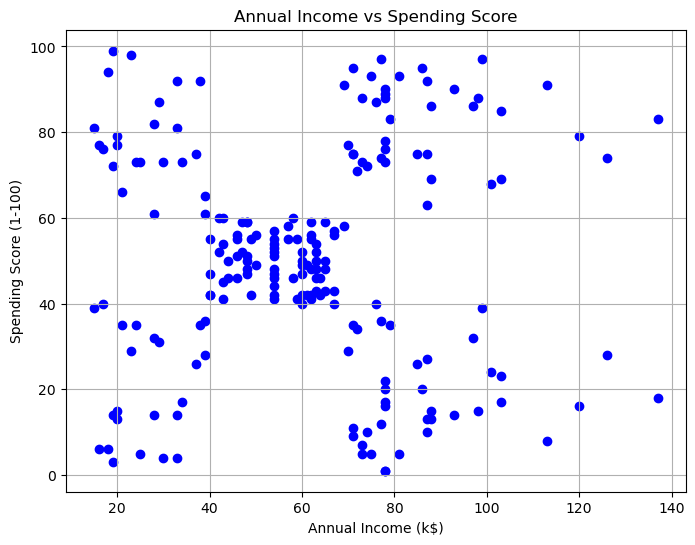

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color='blue')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.grid(True)
plt.show()


In [13]:
y_pred = model.predict(X_test)


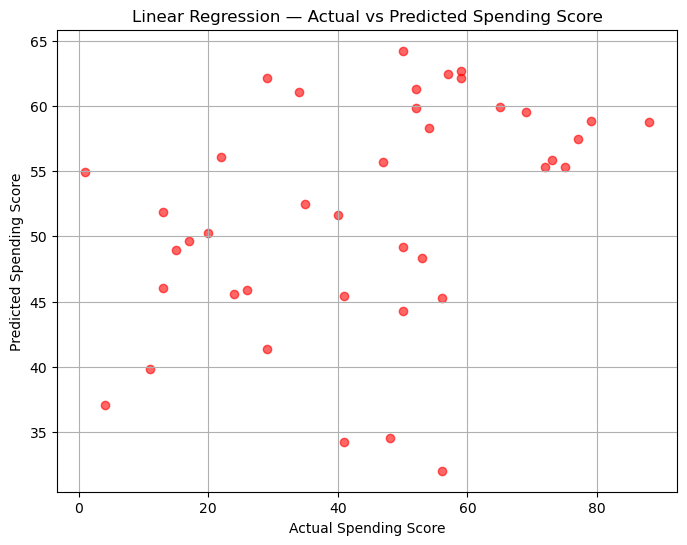

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='red', alpha=0.6)
plt.xlabel("Actual Spending Score")
plt.ylabel("Predicted Spending Score")
plt.title("Linear Regression — Actual vs Predicted Spending Score")
plt.grid(True)
plt.show()


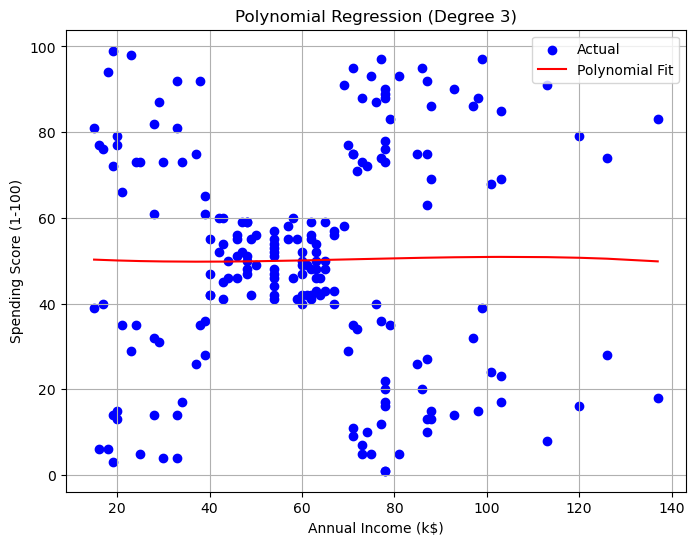

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

X = df[['Annual Income (k$)']]
y = df['Spending Score (1-100)']

model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, y_pred, color='red', label='Polynomial Fit')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Polynomial Regression (Degree 3)')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

X = df[['Age', 'Annual Income (k$)', 'Gender']]
y = df['Spending Score (1-100)']

model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
model.fit(X, y)

print("R²:", model.score(X, y))


R²: 0.34983789930470754


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[['Gender', 'Age', 'Annual Income (k$)']]
y = df['Spending Score (1-100)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R² (test):", r2_score(y_test, y_pred))


R² (test): 0.11193462046979308


C:\Users\amnaj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


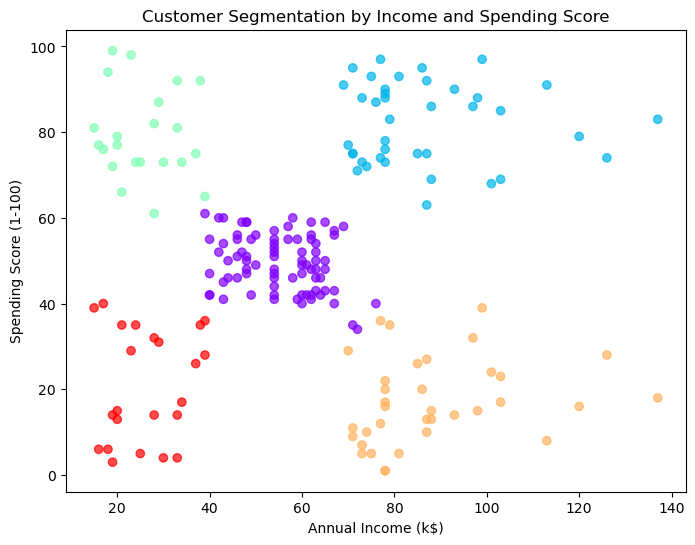

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
            c=df['Cluster'], cmap='rainbow', alpha=0.7)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation by Income and Spending Score')
plt.show()


In [19]:
#kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1       1   19                  15                      39   
1             2       1   21                  15                      81   
2             3       0   20                  16                       6   
3             4       0   23                  16                      77   
4             5       0   31                  17                      40   
..          ...     ...  ...                 ...                     ...   
195         196       0   35                 120                      79   
196         197       0   45                 126                      28   
197         198       1   32                 126                      74   
198         199       1   32                 137                      18   
199         200       1   30                 137                      83   

     Cluster  
0          4  
1          2  
2          4  
3          2  
4          4

C:\Users\amnaj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [20]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load your dataset
# df = pd.read_csv("your_file.csv")

# Drop CustomerID
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
y = df['Cluster']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model (Random Forest usually works better than Logistic Regression here)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[18  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0  3]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00         3

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [22]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())


Cross-validation scores: [0.825 1.    1.    0.95  0.8  ]
Mean accuracy: 0.915


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load your dataset
# df = pd.read_csv("your_file.csv")

# Drop CustomerID
X = df[['Gender', 'Age', 'Annual Income (k$)']]
y = df['Cluster']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model (Random Forest usually works better than Logistic Regression here)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.825
Confusion Matrix:
 [[18  0  0  0  0]
 [ 0  4  0  1  0]
 [ 1  0  2  0  0]
 [ 1  3  0  7  0]
 [ 0  0  1  0  2]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        18
           1       0.57      0.80      0.67         5
           2       0.67      0.67      0.67         3
           3       0.88      0.64      0.74        11
           4       1.00      0.67      0.80         3

    accuracy                           0.82        40
   macro avg       0.80      0.75      0.76        40
weighted avg       0.84      0.82      0.82        40



In [24]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


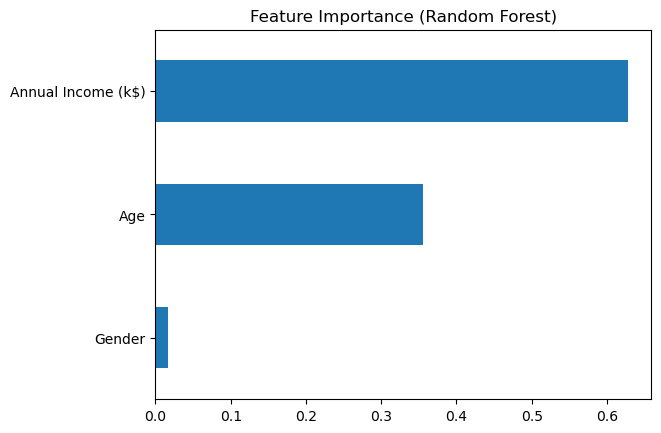

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()


In [30]:
st=pd.read_csv(r"C:\Users\amnaj\OneDrive\Desktop\csv\student_performance.csv")
print(st)

    Study_Hours  Attendance(%)  Assignment_Score Parent_Education  \
0             5             90                85         Bachelor   
1             3             75                70      High School   
2             4             88                78           Master   
3             2             60                65      High School   
4             6             95                92              PhD   
5             1             55                50      High School   
6             4             80                82         Bachelor   
7             2             65                58      High School   
8             5             85                88           Master   
9             3             70                72         Bachelor   
10            6             93                90              PhD   
11            4             78                76           Master   
12            2             60                55      High School   
13            5             87    

In [31]:
st.head()

,Study_Hours,Attendance(%),Assignment_Score,Parent_Education,Extra_Curricular,Internet_Access,Result
0,5,90,85,Bachelor,Yes,Yes,Pass
1,3,75,70,High School,No,No,Fail
2,4,88,78,Master,Yes,Yes,Pass
3,2,60,65,High School,No,No,Fail
4,6,95,92,PhD,Yes,Yes,Pass


In [32]:
st.value_counts()

Study_Hours  Attendance(%)  Assignment_Score  Parent_Education  Extra_Curricular  Internet_Access  Result
1            50             48                High School       No                No               Fail      1
             55             50                High School       No                No               Fail      1
2            60             55                High School       No                No               Fail      1
                            65                High School       No                No               Fail      1
             65             58                High School       No                No               Fail      1
3            70             72                Bachelor          No                Yes              Fail      1
             75             70                High School       No                No               Fail      1
4            78             76                Master            Yes               Yes              Pass      1
      

In [33]:
st.dtypes

Study_Hours          int64
Attendance(%)        int64
Assignment_Score     int64
Parent_Education    object
Extra_Curricular    object
Internet_Access     object
Result              object
dtype: object

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


In [36]:
st_encoded = pd.get_dummies(st, drop_first=True)
st_encoded

,Study_Hours,Attendance(%),Assignment_Score,Parent_Education_High School,Parent_Education_Master,Parent_Education_PhD,Extra_Curricular_Yes,Internet_Access_Yes,Result_Pass
0,5,90,85,False,False,False,True,True,True
1,3,75,70,True,False,False,False,False,False
2,4,88,78,False,True,False,True,True,True
3,2,60,65,True,False,False,False,False,False
4,6,95,92,False,False,True,True,True,True
5,1,55,50,True,False,False,False,False,False
6,4,80,82,False,False,False,True,True,True
7,2,65,58,True,False,False,False,False,False
8,5,85,88,False,True,False,True,True,True
9,3,70,72,False,False,False,False,True,False


In [38]:
# Split features and target
X = st_encoded.drop("Result_Pass", axis=1)
y = st_encoded["Result_Pass"]
X_train, X_test, y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

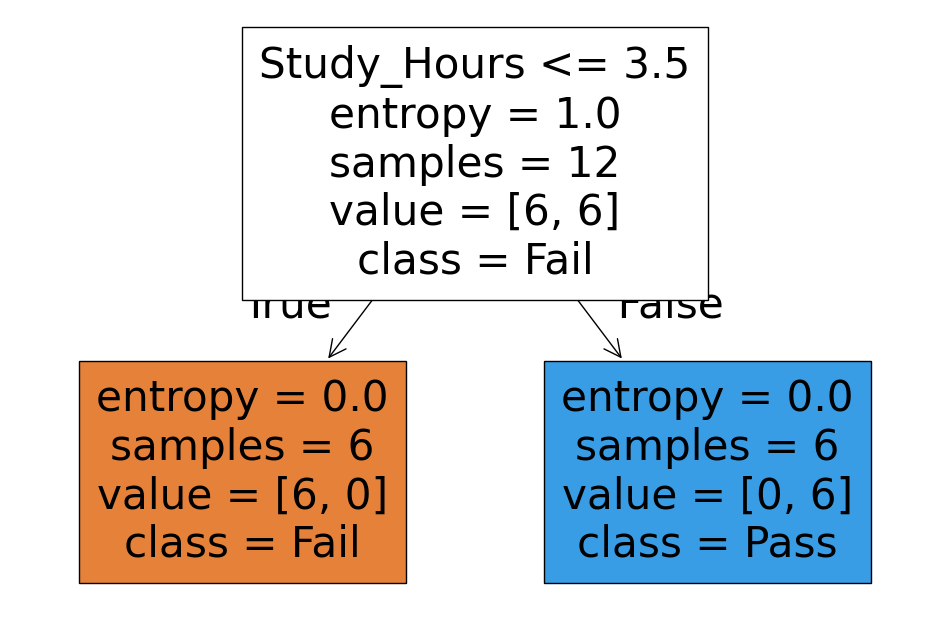

In [39]:
# Plot tree
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True)
plt.show()


In [42]:
y_pred = clf.predict(X_test)
y_pred

array([False,  True,  True,  True, False])

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [47]:
st1=pd.read_csv(r"C:\Users\amnaj\OneDrive\Desktop\csv\student_performance.csv")
print(st1)

    Study_Hours  Attendance(%)  Assignment_Score Parent_Education  \
0             5             90                85         Bachelor   
1             3             75                70      High School   
2             4             88                78           Master   
3             2             60                65      High School   
4             6             95                92              PhD   
5             1             55                50      High School   
6             4             80                82         Bachelor   
7             2             65                58      High School   
8             5             85                88           Master   
9             3             70                72         Bachelor   
10            6             93                90              PhD   
11            4             78                76           Master   
12            2             60                55      High School   
13            5             87    

In [52]:
st1.drop(columns="Parent_Education")

,Study_Hours,Attendance(%),Assignment_Score,Extra_Curricular,Internet_Access,Result
0,5,90,85,Yes,Yes,Pass
1,3,75,70,No,No,Fail
2,4,88,78,Yes,Yes,Pass
3,2,60,65,No,No,Fail
4,6,95,92,Yes,Yes,Pass
5,1,55,50,No,No,Fail
6,4,80,82,Yes,Yes,Pass
7,2,65,58,No,No,Fail
8,5,85,88,Yes,Yes,Pass
9,3,70,72,No,Yes,Fail


In [53]:
st1_encoded = pd.get_dummies(st, drop_first=True)
st1_encoded

,Study_Hours,Attendance(%),Assignment_Score,Parent_Education_High School,Parent_Education_Master,Parent_Education_PhD,Extra_Curricular_Yes,Internet_Access_Yes,Result_Pass
0,5,90,85,False,False,False,True,True,True
1,3,75,70,True,False,False,False,False,False
2,4,88,78,False,True,False,True,True,True
3,2,60,65,True,False,False,False,False,False
4,6,95,92,False,False,True,True,True,True
5,1,55,50,True,False,False,False,False,False
6,4,80,82,False,False,False,True,True,True
7,2,65,58,True,False,False,False,False,False
8,5,85,88,False,True,False,True,True,True
9,3,70,72,False,False,False,False,True,False


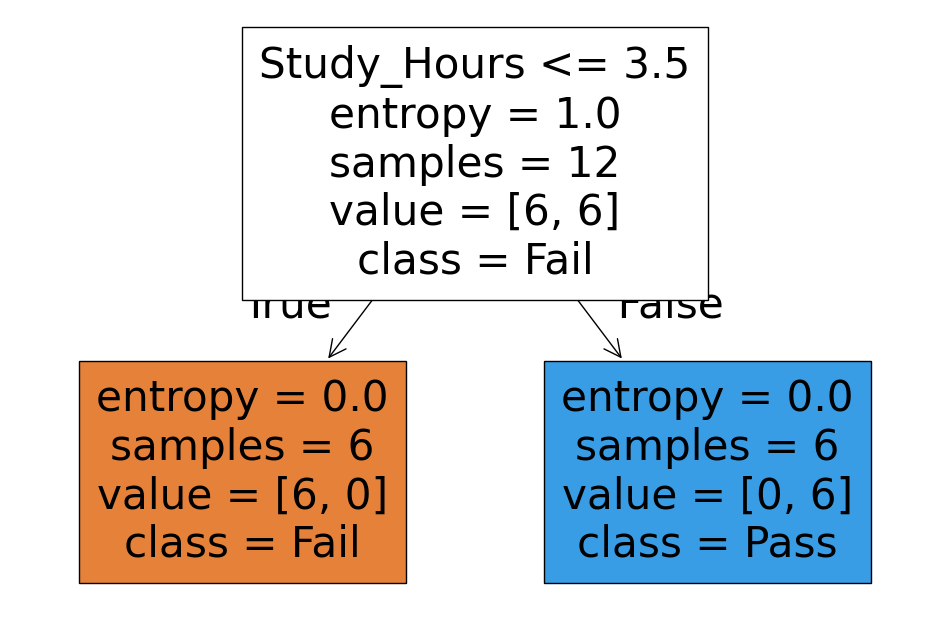

In [56]:
X = st1_encoded.drop(columns=["Result_Pass"])
y = st1_encoded["Result_Pass"]
X_train, X_test, y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
clf.fit(X_train, y_train)
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True)
plt.show()

In [57]:
y_pred = clf.predict(X_test)
y_pred

array([False,  True,  True])

In [58]:


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0
